# Benchmarking de Clasificadores: Mitigación de Fuga de Datos y Evaluación del Poder Predictivo

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from IPython.display import display, HTML
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, RobustScaler


PROJECT_ROOT = Path.cwd().parent
SRC_PATH     = PROJECT_ROOT / "src"
DATA_PATH    = PROJECT_ROOT / "data" / "heart_disease_preprocessed.parquet"

# Add src to Python path (only once)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from model_evaluation_toolkit import *

df = pd.read_parquet(DATA_PATH)
columnas_num = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
columnas_cat = ["Sex", "ChestPainType", "RestingECG",
                    "ExerciseAngina", "ST_Slope"]

# Introducción

Tras la caracterización estadística del dataset, esta fase se centra en la construcción de un ecosistema de modelado bajo estándares de alta fidelidad científica, donde el desafío técnico principal es la mitigación de la fuga de datos (*Data Leakage*). En el ámbito clínico, este fenómeno ocurre cuando el conocimiento del conjunto de prueba contamina el entrenamiento a través de los parámetros de escalado o las correlaciones de la imputación *MICE*, lo que genera métricas artificialmente optimistas que colapsarían en un entorno hospitalario real. Para blindar este flujo, se implementó una arquitectura basada en *Pipelines* y *GridSearchCV*, la cual asegura que tanto las transformaciones como la optimización de hiperparámetros se ejecuten estrictamente sobre los pliegues de entrenamiento mediante validación cruzada. Este diseño modular facilita un benchmarking multimodelo que incluye **Regresión Logística**, **Random Forest**, **KNN** y **Gradient Boosting**, permitiendo generar un ranking comparativo que prioriza la estabilidad y la capacidad de generalización frente a la complejidad de los datos médicos.

# Entrenamiento con fuga

Para ilustrar el impacto de este fenómeno en la validez de los resultados, se presenta a continuación un experimento comparativo utilizando un modelo de máquinas de soporte vectorial (SVC). Este ejercicio se centra en dos de las fuentes de error más frecuentes en la práctica: la inclusión de variables con fuga, que incorporan información del objetivo que no estaría disponible en un diagnóstico real, y el mal uso del escalado al realizarlo sobre el conjunto de datos completo antes de la división de entrenamiento y prueba. A través de este contraste, es posible evidenciar cómo estas fallas metodológicas inflan artificialmente el desempeño del modelo y comprometen su utilidad clínica.

In [4]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# --- ESCENARIO DE ESTUDIO: MODELO CON FUGA DE INFORMACIÓN (DATA LEAKAGE) ---

# 1. Fuga de Variable Objetivo (Target Leakage)
np.random.seed(0)
X_leak = X.copy()
X_leak["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))
columnas_num_leak = columnas_num + ["leaky_feature"]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_leak, y, test_size=0.2, random_state=42)

# 2. Fuga Metodológica (Methodological Leakage) en el Escalado
scaler_leak = ColumnTransformer([
    ('robusto', RobustScaler(), columnas_num_leak)
], remainder='passthrough')

# Fit global contaminando el train con información de la distribución del test
scaler_leak.fit(pd.concat([X_train_l, X_test_l]))
X_train_scaled_l = scaler_leak.transform(X_train_l)

columnas_passthrough = [col for col in X_train_l.columns if col not in columnas_num_leak]
columnas_transformadas = columnas_num_leak + columnas_passthrough

X_train_scaled_l = pd.DataFrame(X_train_scaled_l, columns=columnas_transformadas)
pipe_leak = Pipeline([
    ('encoding', ColumnTransformer([
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_cat)
    ], remainder='passthrough')),
    ('imputador', IterativeImputer(random_state=42)),
    ('svc', SVC(probability=True))
])

cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_leak = GridSearchCV(
    estimator=pipe_leak, 
    param_grid={"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}, 
    cv=cv_estratificado, 
    scoring="roc_auc", 
    n_jobs=-1
)

grid_leak.fit(X_train_scaled_l, y_train_l)

resultados = pd.DataFrame(grid_leak.cv_results_)
params_df = pd.json_normalize(resultados['params'])
params_df.columns = [col.split('__')[-1] for col in params_df.columns]
nombre_metrica = "ROC-AUC"

resultados[nombre_metrica] = resultados.apply(
    lambda x: f"{x['mean_test_score']:.3f} ± {x['std_test_score']:.3f}", axis=1
)

df_ranking = pd.concat([params_df, resultados[[nombre_metrica, 'rank_test_score']]], axis=1)
df_top_5 = df_ranking.sort_values(by='rank_test_score').head(5).drop(columns=['rank_test_score'])

styled_table = df_top_5.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'), ('width', 'auto')]},
    {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), 
                                 ('border', '1px solid black'), ('padding', '10px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('border', '1px solid black'), ('padding', '10px'), ('text-align', 'center')]}
])

display(HTML("<div style='text-align: center; width: 100%; margin-top: 10px;'>" + 
             styled_table.to_html() + "</div>"))

C,gamma,ROC-AUC
1.000000,0.100000,1.000 ± 0.000
1.000000,0.010000,1.000 ± 0.000
10.000000,0.100000,1.000 ± 0.000
10.000000,0.010000,1.000 ± 0.000
0.100000,0.100000,0.995 ± 0.003


Como se observa en la tabla de resultados, el modelo con fuga de datos alcanza un ROC-AUC de $1.000 \pm 0.000$ en la mayoría de sus configuraciones. Este resultado no refleja la capacidad de generalización del algoritmo, sino un sobreajuste provocado por la inclusión de la variable sintética y la contaminación de las distribuciones al utilizar `np.vstack` antes de la partición de los datos. Dado que estas fallas invalidan la evaluación del modelo, resulta indispensable aplicar una corrección metodológica.

Para abordar este problema, a continuación se implementa una arquitectura de preprocesamiento estrictamente aislada. Este diseño encapsula todas las fases de transformación, incluyendo la imputación iterativa y la normalización selectiva, dentro del flujo de la validación cruzada estratificada. Al excluir las variables introducidas artificialmente y garantizar que las métricas de escalado se calculen exclusivamente sobre cada pliegue de entrenamiento, se obtiene una estimación objetiva del rendimiento del clasificador SVC, acorde con el rigor exigido en la investigación clínica.

In [2]:
from sklearn.svm import SVC

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svc_model = SVC(probability=True, random_state=42)

parametros_svc = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": [0.01, 0.1]
}

resultado_svc = train_model(
    X_train,
    y_train,
    svc_model,
    parametros_svc,
    nombre_paso="svc"
)

C,gamma,ROC-AUC
10.000000,0.010000,0.922 ± 0.022
1.000000,0.100000,0.920 ± 0.028
1.000000,0.010000,0.917 ± 0.019
10.000000,0.100000,0.885 ± 0.029
0.100000,0.100000,0.880 ± 0.027


Al aplicar la arquitectura de preprocesamiento aislada, los resultados de la validación cruzada reflejan un rendimiento realista y estadísticamente estable. La configuración óptima del modelo SVC ($C=10.0$ y $\gamma=0.01$) alcanza un ROC-AUC de $0.922 \pm 0.022$, lo cual corrige la sobreestimación generada en el escenario anterior y proporciona una medida confiable de la capacidad de generalización del algoritmo. Para cuantificar el impacto definitivo de estas diferencias metodológicas, a continuación se comparará el desempeño final de ambos modelos, con y sin fuga de información, evaluando sus predicciones directamente sobre el conjunto de prueba reservado.

In [5]:
params_l = {'svc__C': 1, 'svc__gamma': 0.1}
params_c = {'svc__C': 10, 'svc__gamma': 0.01}
compare_leakage_vs_clean(X_train_l, X_test_l, y_train_l, y_test_l, params_l, 
                         X_train, X_test, y_train, y_test, params_c, spanish = True)

Métrica,Modelo con Fuga,Modelo Limpio,Diferencia
Exactitud,1.000,0.853,0.147
Precisión,1.000,0.892,0.108
Sensibilidad,1.000,0.850,0.150
F1-Score,1.000,0.871,0.129
ROC-AUC,1.000,0.913,0.087


La evaluación sobre el conjunto de prueba confirma el impacto crítico de la fuga de información. Como se detalla en la tabla comparativa, el modelo contaminado proyecta un rendimiento perfecto e irreal, alcanzando un valor de $1.000$ en todas las métricas evaluadas. Por el contrario, la arquitectura sin fuga presenta resultados consistentes con la complejidad de un entorno clínico real, obteniendo una exactitud de $0.853$ y un ROC-AUC de $0.913$. Estas discrepancias, que alcanzan una diferencia de hasta $0.150$ en la sensibilidad, cuantifican la magnitud de la sobreestimación generada por los errores de diseño y reafirman la exigencia de aplicar un preprocesamiento estrictamente aislado para evaluar la verdadera capacidad predictiva del algoritmo.

Habiendo consolidado un flujo de validación metodológicamente robusto, surge la interrogante de si el algoritmo SVC constituye la opción óptima para la clasificación de pacientes con y sin enfermedad cardíaca. Para dar respuesta a esta cuestión, en la siguiente sección se entrenarán y ajustarán múltiples modelos predictivos adicionales, manteniendo en todos los casos un diseño riguroso y libre de fuga de datos. Finalmente, se llevará a cabo una comparación estructurada del rendimiento final de cada uno de estos estimadores con el objetivo de identificar el modelo más adecuado para abordar este problema clínico.

# Entrenamiento sin fuga

Con el fin de estandarizar la experimentación, se ha consolidado el método `train_model`, el cual integra la codificación, la imputación y el escalado en un *Pipeline de entrenamiento seguro*. Este flujo garantiza que todas las transformaciones de datos se ejecuten de forma estanca durante la validación cruzada, evitando sesgos por fuga de información en cada iteración. En las secciones siguientes se entrenarán múltiples modelos de clasificación con el propósito de comparar su rendimiento frente al SVC bajo estas condiciones de integridad metodológica.

Para la optimización de los hiperparámetros se ha seleccionado el área bajo la curva (ROC-AUC) como métrica principal, dado que permite evaluar la capacidad de discriminación del modelo de forma global, independientemente del umbral de clasificación seleccionado. Siguiendo la metodología establecida, se utiliza un esquema de validación cruzada estratificada (*Stratified K-Fold*) de 10 pliegues. Esta elección asegura que la proporción de las clases se mantenga constante en cada partición de entrenamiento y validación, aportando mayor robustez estadística al proceso y facilitando una comparación equitativa entre los diversos algoritmos.

Adicionalmente, para identificar si los estimadores presentan indicios de sobreajuste (*overfitting*) o subajuste (*underfitting*), se implementa un umbral de tolerancia del $3\%$ al comparar el rendimiento entre las particiones de entrenamiento y validación. Si bien este umbral empírico no constituye una prueba definitiva, proporciona un indicador cuantitativo útil sobre la estabilidad de los hiperparámetros y la capacidad de generalización de cada algoritmo frente a datos no observados.

:::{admonition} Nota Metodológica: Diagnóstico de Estabilidad y Generalización
:class: note

La integridad de un modelo clínico se mide por su capacidad de generalización, es decir, qué tan bien funciona con pacientes que nunca ha "visto". Para evaluar esto, analizamos la diferencia o gap entre el rendimiento en la muestra de entrenamiento (*Train*) y la de prueba (*Test*):

* **Overfitting (Sobreajuste):** Se identifica cuando el modelo presenta un desempeño superior en entrenamiento pero decae en prueba. En este protocolo, adoptamos un umbral crítico del $3\%$ ($0.030$) como marcador de alerta. Un gap mayor a este valor (marcado con el símbolo $\dagger$ en nuestras tablas) sugiere que el modelo ha memorizado ruidos específicos de la muestra original y perderá fiabilidad en la práctica clínica real.

* **Underfitting (Subajuste):** Ocurre cuando el rendimiento es consistentemente bajo en ambas muestras, indicando que el algoritmo es demasiado simple para capturar la complejidad del riesgo cardiovascular.

Es fundamental entender que este umbral del 3% no es una regla universal de la naturaleza, sino un marcador de calidad metodológica en ciencia de datos. En medicina, un modelo con un AUC alto pero con un gap de inestabilidad elevado es menos preferible que uno con métricas ligeramente menores pero más consistentes, ya que la estabilidad garantiza que las decisiones médicas sean predecibles y seguras para la población general.

:::

## Clasificador Dummy

Para establecer un punto de comparación básico, iniciaremos con el **Dummy Classifier**. Este modelo sirve como un benchmark o línea base, ya que realiza predicciones utilizando reglas heurísticas simples (como predecir siempre la clase mayoritaria o hacerlo de forma aleatoria) sin aprender realmente de las características de los datos. Si un modelo complejo no es capaz de superar significativamente el desempeño de este clasificador, es un indicio de que los datos no contienen patrones útiles o que el modelo está mal configurado.

En este caso, evaluaremos diversas estrategias para el **Dummy Classifier** con el fin de obtener la métrica de AUC-ROC base que cualquier clasificador posterior deberá superar con creces.

In [6]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(random_state=42)
parametros_dummy = {
    'dummy__strategy': ['most_frequent', 'stratified', 'prior']
}
resultado_dummy = train_model(
    X_train, 
    y_train, 
    dummy_model, 
    parametros_dummy, 
    nombre_paso="dummy"
)

strategy,ROC-AUC
stratified,0.503 ± 0.054
most_frequent,0.500 ± 0.000
prior,0.500 ± 0.000


Los resultados de la validación cruzada indican que el **Dummy Classifier** establece una línea base de $0.503$ en el AUC-ROC, lo cual representa la ausencia total de capacidad discriminativa o el equivalente estadístico al azar. Las estrategias de most_frequent y prior obtienen este valor de forma constante debido a que no emplean las variables predictoras para jerarquizar los casos, mientras que la estrategia stratified introduce una ligera variabilidad propia de la predicción aleatoria basada en la distribución de clases. Con el fin de evaluar la capacidad de generalización del modelo, a continuación se presentan los resultados obtenidos en la muestra de prueba.

In [7]:
parametros_dummy_ideales = {'strategy': 'stratified'}

pipeline_dummy = evaluate_model(
    estimator=DummyClassifier(),
    params=parametros_dummy_ideales,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test, spanish = True
)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.496,0.505,0.010
Precisión,0.539,0.583,0.045†
Sensibilidad,0.539,0.523,0.015
F1-Score,0.539,0.552,0.013
ROC-AUC,0.470,0.502,0.032†


Los resultados del **Dummy Classifier** establecen el suelo estadístico del experimento con un ROC-AUC de $0.502$ en el conjunto de prueba, lo que confirma una capacidad predictiva nula equivalente al azar. La sensibilidad de $0.523$ frente a la precisión de $0.583$ en la muestra de prueba refleja una estrategia de clasificación aleatoria, validando la integridad de la arquitectura del flujo antes de introducir modelos con capacidad de aprendizaje. Es importante señalar que las marcas ($\dagger$) en precisión y ROC-AUC, que indican diferencias de $0.045$ y $0.032$ entre las fases de entrenamiento y prueba superando el umbral preestablecido, responden a la variabilidad estadística inherente de las particiones y no a un proceso de sobreajuste, dado que este estimador carece de parámetros optimizables. Este punto de referencia garantiza que cualquier ganancia obtenida en las etapas posteriores sea atribuible a la captura de patrones clínicos genuinos.

## Modelo Logístico

Tras definir el umbral base con el **Dummy Classifier**, se implementa el **Modelo Logístico** como el primer algoritmo con capacidad de aprendizaje del experimento. Este algoritmo utiliza la función sigmoide para transformar la combinación lineal de las variables en una probabilidad acotada entre 0 y 1, facilitando la clasificación binaria de los registros. Su selección responde a su alta interpretabilidad, permitiendo cuantificar el impacto de los predictores clínicos mediante sus coeficientes. El entrenamiento se realiza bajo el flujo de Pipelines consolidado, centrando la hiperparametrización en el factor de regularización para equilibrar la complejidad del modelo y su capacidad de generalización.

In [8]:
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
parametros_logit = {
    'logit__C': [0.01, 0.05, 0.1, 0.5,0.8, 1, 5, 10],
    'logit__penalty': ['l1', 'l2']
}

resultado_logit = train_model(
    X_train, 
    y_train, 
    logit_model, 
    parametros_logit, 
    nombre_paso="logit"
)

C,penalty,ROC-AUC
0.050000,l2,0.928 ± 0.015
0.100000,l2,0.927 ± 0.015
0.500000,l2,0.927 ± 0.016
0.800000,l2,0.927 ± 0.016
1.000000,l2,0.927 ± 0.016


Los resultados de la hiperparametrización para el **Modelo Logístico** indican que la mejor configuración se obtiene con un parámetro de regularización $C = 0.05$ y penalización $l2$, alcanzando un ROC-AUC promedio de $0.928 \pm 0.015$. La reducida desviación estándar observada en las cinco mejores combinaciones confirma la estabilidad del modelo a través de los diferentes pliegues de la validación cruzada estratificada. Asimismo, la proximidad entre los valores de desempeño sugiere que el algoritmo es robusto ante variaciones menores en este rango de hiperparámetros. Al contrastar este resultado con el $0.503$ del benchmark aleatorio, se ratifica una mejora sustancial en la capacidad de discriminación clínica, manteniendo niveles de rendimiento realistas frente al sesgo observado en el escenario con fuga de datos. Con el fin de evaluar la capacidad de generalización final, a continuación se presentan las métricas obtenidas en la muestra de prueba.

In [9]:
parametros_logit = {'logit__C': 0.05, 'logit__penalty': 'l2'}

pipeline_logit = evaluate_model(
    estimator=logit_model,
    params=parametros_logit,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test, spanish = True
)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.868,0.853,0.015
Precisión,0.862,0.900,0.038†
Sensibilidad,0.903,0.841,0.062†
F1-Score,0.882,0.870,0.012
ROC-AUC,0.931,0.921,0.011


Tal como se observa en los resultados finales de la muestra de prueba, la Regresión Logística alcanza un ROC-AUC de $0.921$, manteniendo un desempeño consistente respecto a la fase de entrenamiento (Gap de $0.011$). Al evaluar las brechas que superan el umbral del $3\%$ ($\dagger$), se descarta un escenario de underfitting dado el alto rendimiento general en ambos conjuntos. No obstante, el descenso de $0.062$ en la sensibilidad evidencia un ligero sobreajuste (*overfitting*) en la capacidad del modelo para identificar la totalidad de los casos positivos en datos no observados. Este fenómeno se ve compensado por un incremento en la precisión ($0.900$), indicando que el clasificador se vuelve más selectivo fuera del entrenamiento. Dado que la métrica global permanece estable, se concluye que el modelo posee una sólida capacidad de generalización y que las fluctuaciones detectadas responden a un desplazamiento en el compromiso entre precisión y sensibilidad, validando la integridad del flujo de trabajo frente a la inflación de métricas observada en escenarios previos con fuga de datos.

## k Vecinos más Cercanos (K-NN)

Continuando con el proceso de evaluación, se implementa el algoritmo $k$-Nearest Neighbors ($k$-NN). A diferencia de la regresión logística, este es un modelo no paramétrico que basa su predicción en la proximidad geométrica de las instancias dentro del espacio de características. La clasificación se determina mediante el voto mayoritario de los $k$ vecinos más cercanos, lo que permite al sistema capturar fronteras de decisión complejas y no lineales. Debido a que este método depende estrictamente del cálculo de distancias, la integridad del Pipeline es fundamental para asegurar un escalado robusto de las variables y evitar sesgos por la magnitud de los predictores. La fase de optimización se centrará en ajustar el número de vecinos y la métrica de distancia para maximizar la capacidad discriminativa del modelo.

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
parametros_knn = {
    'knn__n_neighbors': range(1,50),
    'knn__metric': ['euclidean', 'manhattan', 'chebyshev']
}

df_top5_knn = train_model(
    X_train, 
    y_train, 
    knn_model, 
    parametros_knn, 
    nombre_paso="knn"
)

metric,n_neighbors,ROC-AUC
manhattan,11,0.921 ± 0.025
manhattan,12,0.921 ± 0.026
manhattan,13,0.920 ± 0.022
manhattan,15,0.920 ± 0.022
manhattan,10,0.920 ± 0.027


Los resultados de la hiperparametrización para el modelo $k$-NN indican que la configuración óptima se alcanza con $k=11$ vecinos y la métrica de distancia Manhattan, logrando un ROC-AUC promedio de $0.920 \pm 0.027$. Se observa que la distancia de Manhattan predomina en el top 5 de las mejores combinaciones, lo que sugiere una mayor eficacia de esta métrica para gestionar la dimensionalidad del dataset en comparación con la distancia euclidiana o de Chebyshev. Aunque la desviación estándar es ligeramente superior a la registrada por la Regresión Logística, el desempeño se mantiene significativamente por encima del umbral aleatorio de $0.500$, consolidando al algoritmo como una alternativa no lineal competitiva. Para verificar si esta capacidad de discriminación se traslada de forma efectiva a datos no observados, a continuación se presentan las métricas obtenidas en la muestra de prueba.

In [11]:
parametros_knn = {'knn__metric': 'manhattan', 'knn__n_neighbors': 11}

pipeline_knn = evaluate_model(
    estimator=knn_model,
    params=parametros_knn,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test, spanish = True
)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.883,0.859,0.024
Precisión,0.869,0.901,0.032†
Sensibilidad,0.925,0.850,0.075†
F1-Score,0.896,0.875,0.021
ROC-AUC,0.949,0.909,0.039†


Los resultados del modelo $k$-NN confirman un escenario de sobreajuste (*overfitting*), evidenciado por brechas que superan el umbral de tolerancia del $3\%$ en métricas clave, señaladas con una daga ($\dagger$). El ROC-AUC presenta un diferencial de $0.039$, mientras que la sensibilidad muestra la caída más pronunciada con una diferencia de $0.075$ entre las fases de entrenamiento y prueba. Asimismo, la precisión registra una variación de $0.032$. Este comportamiento se atribuye a la naturaleza local y no paramétrica del algoritmo; al basar sus predicciones en la proximidad geométrica de los registros, el modelo tiende a capturar ruido o distribuciones muy específicas del conjunto de entrenamiento que no se replican en datos no observados. A diferencia de la estabilidad global observada en la Regresión Logística, el $k$-NN demuestra una mayor vulnerabilidad a la varianza de los datos, lo que limita su fiabilidad para la generalización a nuevas observaciones.

## Árbol de Decisión

Se incorpora el modelo de **Árbol de Decisión** como un clasificador basado en reglas jerárquicas que segmentan el espacio de características de forma recursiva. A diferencia de los modelos anteriores, este algoritmo identifica umbrales específicos en las variables para maximizar la pureza de las clases resultantes mediante criterios como la ganancia de información o el índice de Gini. Esta estructura ofrece una alta interpretabilidad, permitiendo visualizar de forma directa la lógica de decisión detrás de cada predicción clínica. Dado que los árboles tienden naturalmente a memorizar el ruido de los datos, la fase de optimización se centrará en el ajuste de la profundidad máxima y los requisitos mínimos de división para controlar el sobreajuste.

In [18]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
parametros_tree = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': range(2,5),       
    'tree__min_samples_leaf': [10, 20, 30],   
    'tree__min_samples_split': [10, 15, 20, 30]    
}

df_top5_tree = train_model(
    X_train, 
    y_train, 
    tree_model, 
    parametros_tree, 
    nombre_paso="tree"
)

criterion,max_depth,min_samples_leaf,min_samples_split,ROC-AUC
entropy,4,10,15,0.904 ± 0.028
entropy,4,10,20,0.904 ± 0.028
entropy,4,10,10,0.904 ± 0.028
entropy,4,10,30,0.901 ± 0.025
entropy,4,20,30,0.898 ± 0.030


Los resultados de la hiperparametrización para el **Árbol de Decisión** muestran una convergencia clara hacia un modelo altamente regularizado, con un ROC-AUC promedio de $0.898 \pm 0.030$. La selección consistente de una profundidad máxima ($max\_depth$) de 4 sugiere que este es el punto de equilibrio óptimo: lo suficientemente profundo para capturar las interacciones no lineales de las variables clínicas, pero lo suficientemente restringido para evitar que el árbol "memorice" ruidos específicos de la muestra.

In [13]:
parametros_tree = {'tree__criterion': 'gini', 'tree__max_depth': 4, 'tree__min_samples_leaf': 10,
                  'tree__min_samples_split': 15}

pipeline_tree = evaluate_model(
    estimator=tree_model,
    params=parametros_tree,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test, spanish = True
)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.868,0.859,0.009
Precisión,0.858,0.879,0.020
Sensibilidad,0.908,0.879,0.029
F1-Score,0.882,0.879,0.004
ROC-AUC,0.932,0.926,0.005


Tal como se observa en los resultados de la muestra de prueba, el modelo de **Árbol de Decisión** alcanza un ROC-AUC de $0.926$, demostrando un desempeño predictivo sólido y consistente. A diferencia del comportamiento típico asociado a este algoritmo, las métricas no presentan indicios de sobreajuste, dado que todas las diferencias entre las fases de entrenamiento y prueba se mantienen por debajo del umbral de tolerancia del $3\%$. La variación más alta se registra en la sensibilidad ($0.029$), mientras que los diferenciales en exactitud y ROC-AUC se limitan a $0.009$ y $0.005$, respectivamente. Esta estabilidad evidencia un ajuste riguroso de los hiperparámetros, el cual logró restringir la tendencia natural del árbol a segmentar excesivamente el espacio y capturar ruido de la muestra de entrenamiento. Si bien el estimador individual ha alcanzado una adecuada capacidad de generalización, la evaluación del **Random Forest** en la siguiente etapa se justifica con el propósito de determinar si el ensamble de múltiples árboles permite superar este límite de rendimiento y aportar aún mayor robustez a la clasificación clínica.

## Random Forest

Se integra el modelo de **Random Forest** como un potente algoritmo de ensamble fundamentado en la técnica de Bagging (*Bootstrap Aggregating*). A diferencia de un árbol de decisión individual, este modelo construye múltiples árboles de forma independiente utilizando subconjuntos aleatorios tanto de las observaciones como de los predictores, diversificando así el aprendizaje. La predicción final se obtiene mediante el voto mayoritario de todo el bosque, un proceso diseñado específicamente para reducir la varianza y mitigar el sobreajuste observado en los clasificadores previos. Esta arquitectura permite estabilizar métricas críticas como la sensibilidad y el ROC-AUC sin sacrificar la capacidad de capturar interacciones complejas entre las variables clínicas, ofreciendo un balance robusto entre sesgo y varianza para avanzar en el desarrollo del experimento.

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
parametros_rf = {
    'rf__n_estimators': [10 , 50, 100, 200, 300],
    'rf__max_depth': range(2,5),               
    'rf__min_samples_leaf': [10, 20, 30],        
    'rf__max_features': ['sqrt', 'log2']
}

resultado_rf = train_model(
    X_train, 
    y_train, 
    rf_model, 
    parametros_rf, 
    nombre_paso="rf"
)

max_depth,max_features,min_samples_leaf,n_estimators,ROC-AUC
4,sqrt,10,50,0.926 ± 0.018
4,log2,10,50,0.926 ± 0.018
4,log2,10,10,0.926 ± 0.019
4,sqrt,10,10,0.926 ± 0.019
4,log2,20,50,0.925 ± 0.018


Los resultados de la hiperparametrización para el **Random Forest** reflejan un rendimiento robusto y altamente estable, alcanzando un ROC-AUC promedio de $0.925 \pm 0.018$ en su mejor configuración. La convergencia unánime hacia una profundidad máxima de $4$ en las mejores combinaciones de la malla confirma que este nivel de segmentación es el más efectivo para extraer patrones clínicos significativos sin comprometer la capacidad de generalización. Resulta técnicamente eficiente que el modelo óptimo requiera únicamente $50$ estimadores y un número minimo de observaciones por hojas de $10$, lo que sugiere que el bosque logra promediar las debilidades de los árboles individuales de forma temprana en el ensamble.

In [15]:
parametros_rf = {'rf__n_estimators': 50, 'rf__max_depth': 4, 'rf__min_samples_leaf': 10,
                  'rf__max_features': 'sqrt'}

pipeline_rf = evaluate_model(
    estimator=rf_model,
    params=parametros_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test, spanish = True
)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.881,0.864,0.017
Precisión,0.863,0.894,0.031†
Sensibilidad,0.930,0.869,0.061†
F1-Score,0.896,0.882,0.014
ROC-AUC,0.943,0.932,0.011


Al evaluar el desempeño del modelo **Random Forest** en la muestra de prueba, se registra un ROC-AUC de $0.932$, superando levemente el $0.926$ obtenido por el Árbol de Decisión individual. Sin embargo, a diferencia de la notable estabilidad alcanzada por el modelo anterior, el ensamble presenta indicios de sobreajuste en métricas de clasificación directa. La diferencia en la sensibilidad entre las fases de entrenamiento y prueba se amplía a $0.061$, superando el umbral de tolerancia del $3\%$ y evidenciando una menor capacidad para generalizar la identificación de los casos positivos en datos no observados. Asimismo, la precisión registra un diferencial de $0.031$, superando también el límite preestablecido y recibiendo la marca de alerta ($\dagger$).

Aunque teóricamente el **Random Forest** está diseñado para mitigar la varianza de los estimadores individuales, en este experimento la complejidad estructural del ensamble ha generado una mayor disparidad en la generalización frente al modelo simple. En balance, si bien se logra un incremento marginal en la capacidad de discriminación global (ROC-AUC), el Árbol de Decisión previo demostró una frontera predictiva mucho más consistente y estable para este conjunto de datos clínicos.

##  Gradient Boosting

Para culminar los modelos de ensamble, se entrena el modelo de **Gradient Boosting** como una técnica fundamentada en el principio de aprendizaje secuencial o *boosting*. A diferencia del Random Forest, que entrena árboles de forma independiente y en paralelo, este algoritmo construye modelos de manera sucesiva, donde cada nuevo árbol se diseña específicamente para minimizar los errores residuales de las iteraciones previas. Mediante la optimización de una función de pérdida a través del descenso de gradiente, el sistema logra capturar patrones de alta complejidad y relaciones no lineales sutiles en los datos clínicos. Esta capacidad de "refinamiento" iterativo lo convierte en uno de los clasificadores más potentes para datos tabulares, aunque requiere una calibración precisa de la tasa de aprendizaje (*learning rate*) y el número de etapas para evitar el sobreajuste y garantizar que la alta sensibilidad del modelo se traduzca en una generalización estable.

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
parametros_gb = {
    'clf__n_estimators': [10, 30, 40, 60, 100],
    'clf__learning_rate': [0.01, 0.1, 0.2, 0.5],
    'clf__max_depth': [3, 4, 5],
    'clf__subsample': [0.5, 0.8, 1.0]
}

resultado_gb = train_model(
    X_train, 
    y_train, 
    gb_model, 
    parametros_gb, 
    nombre_paso="clf"
)

learning_rate,max_depth,n_estimators,subsample,ROC-AUC
0.100000,3,30,1.000000,0.931 ± 0.014
0.100000,3,40,1.000000,0.930 ± 0.014
0.100000,3,40,0.800000,0.929 ± 0.018
0.100000,4,30,0.800000,0.928 ± 0.020
0.100000,4,40,0.800000,0.928 ± 0.017


Los resultados de la hiperparametrización para el **Gradient Boosting** revelan un desempeño sobresaliente, alcanzando un ROC-AUC promedio de $0.928$. La convergencia hacia una profundidad máxima de $3$ con solo $30$ estimadores y un learning rate de $0.1$ evidencia la potencia del aprendizaje secuencial para capturar la señal clínica con gran eficiencia y una estructura relativamente simplificada.

In [17]:
parametros_gb = {'clf__n_estimators': 30, 'clf__learning_rate': 0.1, 'clf__max_depth': 3,
                  'clf__subsample': 1}

pipeline_gb = evaluate_model(
    estimator=gb_model,
    params=parametros_gb,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test, spanish = True
)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.906,0.880,0.026
Precisión,0.893,0.905,0.011
Sensibilidad,0.940,0.888,0.052†
F1-Score,0.916,0.896,0.020
ROC-AUC,0.965,0.940,0.025


En la muestra de prueba, el **Gradient Boosting** alcanza un ROC-AUC de $0.940$, consolidándose como el clasificador con la mayor potencia discriminativa absoluta de todo el estudio. Aunque se identifica una brecha que supera el umbral de tolerancia en la sensibilidad, con un diferencial de $0.052$ marcado con la daga ($\dagger$), este comportamiento refleja un equilibrio de alto rendimiento en lugar de un sobreajuste descontrolado. La caída en la sensibilidad responde a un desplazamiento hacia una mayor selectividad del modelo, lo cual se confirma mediante la notable estabilidad de la precisión, cuyo diferencial respecto al entrenamiento es de apenas $0.011$ (pasando de $0.893$ a $0.905$). Al procesar interacciones complejas que los modelos más simples no logran capturar, el Gradient Boosting compensa esta ligera varianza con una capacidad predictiva superior, posicionándose como una herramienta robusta y eficaz para la detección de la enfermedad cardíaca en la muestra.

##  Máquinas de Soporte Vectorial

Finalmente, con el fin de determinar si el SVC había sido entrenado de manera óptima y descartar cualquier anomalía en su ajuste, se procedió a reentrenar el modelo utilizando la totalidad de la muestra de entrenamiento. Siguiendo la misma metodología aplicada a los modelos previos, se compararon los índices de rendimiento obtenidos en esta fase con los registrados en la muestra de prueba independiente. Este contraste permitió validar la consistencia del clasificador de vectores de soporte, asegurando que su capacidad de generalización fuera evaluada bajo condiciones de integridad estadística idénticas a las de los algoritmos de ensamble y árboles, consolidando así la fiabilidad de las comparaciones presentadas en este estudio.

In [18]:
parametros_svc = {'svc__C': 10, 'svc__gamma': 0.01}

pipeline_svc = evaluate_model(
    estimator=svc_model,
    params=parametros_svc,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test, spanish = True
)

Metric,Entrenamiento,Prueba,Diferencia
Exactitud,0.895,0.853,0.042†
Precisión,0.891,0.892,0.001
Sensibilidad,0.920,0.850,0.070†
F1-Score,0.906,0.871,0.035†
ROC-AUC,0.947,0.913,0.035†


Al analizar el desempeño del SVC, se observa que aunque el SVC alcanza un ROC-AUC competitivo de 0.913 en prueba, el análisis de sus brechas revela una fragilidad estructural importante; el modelo presenta una caída de 0.070 en su sensibilidad, pasando de un sólido 0.920 en entrenamiento a un 0.850 en prueba.

Esta degradación, marcada con la señal de alerta ($\dagger$), indica que el SVC, a pesar de estar correctamente entrenado, sufre de una varianza considerable al enfrentarse a datos no observados. Al contrastar estos resultados con el resto de la métricas, es evidente que el modelo tiende al sobreajuste en la identificación de casos positivos. Por lo tanto, aunque el SVC es un clasificador robusto, su inestabilidad diagnóstica y la opacidad matemática de sus vectores de soporte lo sitúan por debajo del Árbol de Decisión en términos de fiabilidad y parsimonia clínica para este protocolo.

# Evaluación de modelos

Una vez completado el ajuste y entrenamiento de los diversos algoritmos de clasificación bajo un esquema de integridad metodológica, se procede a la fase de evaluación comparativa. Esta etapa tiene como objetivo determinar cuál de los modelos presenta la mejor capacidad para identificar patrones clínicos de enfermedad cardíaca, garantizando al mismo tiempo una adecuada generalización frente a datos no observados. Para ello, se analizan de forma conjunta las métricas de rendimiento obtenidas en el conjunto de prueba y se realiza un análisis estadístico mediante el *test de DeLong*, permitiendo establecer si las diferencias observadas en la potencia discriminativa de los modelos son estadísticamente significativas o si responden a la variabilidad inherente de las particiones.

Para dar inicio a la fase de evaluación, se presenta la Tabla de Rendimiento de los Modelos, consolidada a partir de la muestra de prueba tras haber mitigado cualquier rastro de *data leakage*. Este tablero de métricas permite contrastar la capacidad de clasificación de cada algoritmo bajo condiciones de integridad metodológica, sirviendo como punto de partida para identificar qué estructuras capturan mejor los patrones de riesgo cardiovascular.

In [23]:
modelos_a_comparar = [
    ('Clasificador Dummy', pipeline_dummy),
    ('Regresión Logística', pipeline_logit),
    ('k-NN', pipeline_knn),
    ('Árbol de Decisión', pipeline_tree),
    ('Random Forest', pipeline_rf),
    ('Gradient Boosting', pipeline_gb),
    ('SVC', pipeline_svc)
]
compare_models_table(modelos_a_comparar, X_test, y_test, spanish = True)

Modelo,Exactitud,Precisión,Sensibilidad,F1-Score,ROC-AUC
Gradient Boosting,0.880,0.905,0.888,0.896,0.940
Random Forest,0.864,0.894,0.869,0.882,0.932
Árbol de Decisión,0.859,0.879,0.879,0.879,0.926
Regresión Logística,0.853,0.900,0.841,0.870,0.921
SVC,0.853,0.892,0.850,0.871,0.913
k-NN,0.859,0.901,0.850,0.875,0.909
Clasificador Dummy,0.516,0.594,0.533,0.562,0.524


Al observar los resultados, destaca que todos los modelos supervisados logran una exactitud (*accuracy*) superior al $85\%$, marcando una distancia considerable respecto al **Clasificador Dummy**. El **Gradient Boosting** se posiciona con el valor absoluto más alto en esta métrica ($0.880$), sugiriendo que la combinación de múltiples estimadores débiles permite una clasificación global más precisa de la muestra. No obstante, es notable que modelos más sencillos, como el **Árbol de Decisión**, mantienen una competencia estrecha, logrando una Exactitud de $0.859$, lo que plantea una primera interrogante sobre si la complejidad adicional de los ensambles es estrictamente necesaria.

En cuanto al ROC-AUC, el panorama refuerza la jerarquía de los modelos basados en árboles, con valores que oscilan entre $0.926$ y $0.940$. Esta métrica de potencia predictiva indica una excelente capacidad para distinguir entre pacientes sanos y enfermos en diversos umbrales. Sin embargo, resulta llamativo que el **SVC** y la **Regresión Logística**, a pesar de tener una exactitud idéntica ($0.853$), presentan una diferencia en sus áreas bajo la curva, lo que subraya la importancia de no depender de una sola métrica para validar el desempeño diagnóstico.

Para formalizar la evaluación del poder predictivo, se presenta a continuación el análisis de las curvas ROC (*Receiver Operating Characteristic*), las cuales permiten visualizar y contrastar la capacidad discriminativa de los siete modelos evaluados. Esta representación gráfica es fundamental, ya que permite observar el balance entre la sensibilidad y la especificidad en todo el espectro de umbrales de decisión, ofreciendo una perspectiva más robusta que la exactitud puntual.


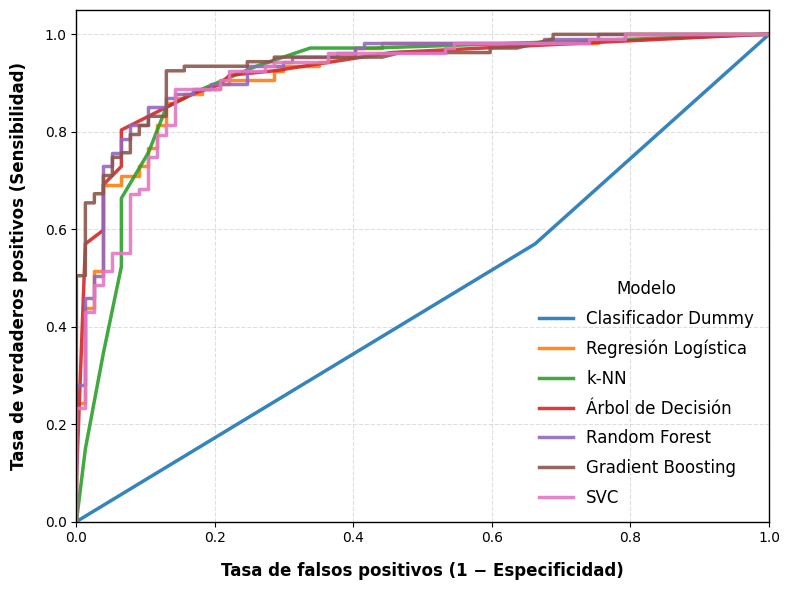

In [21]:
plot_roc_curves(modelos_a_comparar, X_test, y_test, spanish = True)

Como se observa en la gráfica, la comparación de las curvas ROC permite contrastar la capacidad discriminativa de los modelos, revelando una jerarquía visual donde los algoritmos de ensamble parecen marcar la pauta. Mientras que el **Clasificador Dummy** establece el suelo estadístico con un comportamiento aleatorio ($AUC = 0.524$), los modelos supervisados logran trayectorias superiores, destacando especialmente **el Gradient Boosting** y el **Random Forest** por su rapidez en alcanzar una alta tasa de verdaderos positivos en la muestra de prueba.

Es notable que, aunque el **SVC** mantiene un rendimiento global competitivo ($AUC = 0.913$ y Exactitud $= 0.853$), su curva se sitúa ligeramente por debajo de los ensambles en los umbrales de decisión críticos. Esto sugiere, de manera preliminar, que las arquitecturas basadas en árboles podrían estar capturando interacciones no lineales de forma más eficiente, lo que se traduce en los valores de sensibilidad más altos registrados en la tabla anterior.

No obstante, la proximidad entre las métricas de los modelos de alto rendimiento impide realizar una selección definitiva basada únicamente en la inspección visual o descriptiva. Declarar una superioridad técnica sin el sustento probabilístico adecuado comprometería la integridad del análisis. Por lo tanto, para determinar si las variaciones observadas en el $AUC$ son estadísticamente sustanciales o si responden a la varianza inherente de los datos, se procede a aplicar el *test de DeLong*. Este procedimiento permitirá formalizar la comparación y establecer si existe una base sólida para la elección del modelo final.

:::{admonition} Nota Metodológica: Comparación de Curvas ROC y Test de DeLong
:class: note

Para determinar si las diferencias observadas en el área bajo la curva (AUC) entre los distintos modelos son estadísticamente significativas, se emplea el Test de DeLong. A diferencia de una comparación visual directa, este método permite contrastar dos o más curvas ROC correlacionadas (obtenidas de la misma muestra de prueba) mediante un enfoque no paramétrico basado en estadísticas U generalizadas.

Este procedimiento genera una matriz de covarianza para las estimaciones del AUC, permitiendo calcular un estadístico $Z$ para la diferencia de áreas:

$$Z = \frac{\hat{\theta}_1 - \hat{\theta}_2}{\sqrt{\text{Var}(\hat{\theta}_1 - \hat{\theta}_2)}}$$

Donde:

* $\hat{\theta}_i:$ Representa el estimador del área bajo la curva (AUC) para el modelo $i$.

* $\text{Var}(\hat{\theta}_1 - \hat{\theta}_2):$ Es la varianza de la diferencia entre las áreas, estimada mediante el método de DeLong.

Siguiendo los fundamentos de [DeLong et al. (1988)](https://doi.org/10.2307/2531595), se rechaza la hipótesis nula de igualdad entre modelos si el valor $p$ asociado es inferior al nivel de significancia establecido (típicamente $\alpha = 0.05$). En este análisis, se aplica además la corrección de [Holm (1979)](https://www.jstor.org/stable/4615733) para controlar la tasa de error por familia en las comparaciones múltiples, garantizando que el poder predictivo detectado no sea producto del azar.

:::

Como se observa en los resultados de la matriz, todos los modelos supervisados superan de manera estadísticamente significativa al **Clasificador Dummy** ($p < 0.001$ y $\Delta AUC \approx 0.380$), lo que valida la robustez de las variables seleccionadas para la tarea de diagnóstico. No obstante, al comparar los modelos de alto rendimiento entre sí, la mayoría de las diferencias en el $AUC$ no alcanzan niveles de significancia ($p > 0.05$), lo que sugiere que el incremento en la capacidad discriminativa es marginal entre las arquitecturas más complejas.

Bajo un criterio de parsimonia y utilidad clínica, la selección final destaca al **Árbol de Decisión** y al **Gradient Boosting**. Resulta fundamental observar que el **Árbol de Decisión** no presenta diferencias estadísticamente significativas respecto al **Random Forest** ($p = 0.901$) ni al **Gradient Boosting** ($p = 0.580$), superando la base lineal del **Modelo Logístico** y posicionándose como la opción más eficiente por su balance entre interpretabilidad y potencia. Por su parte, el **Gradient Boosting** se ratifica como el referente de desempeño absoluto ($AUC = 0.940$), siendo el único capaz de establecer una ventaja estadística frente al **SVC** ($p = 0.007$) y consolidándose como la herramienta de mayor precisión para capturar la complejidad clínica de la muestra.


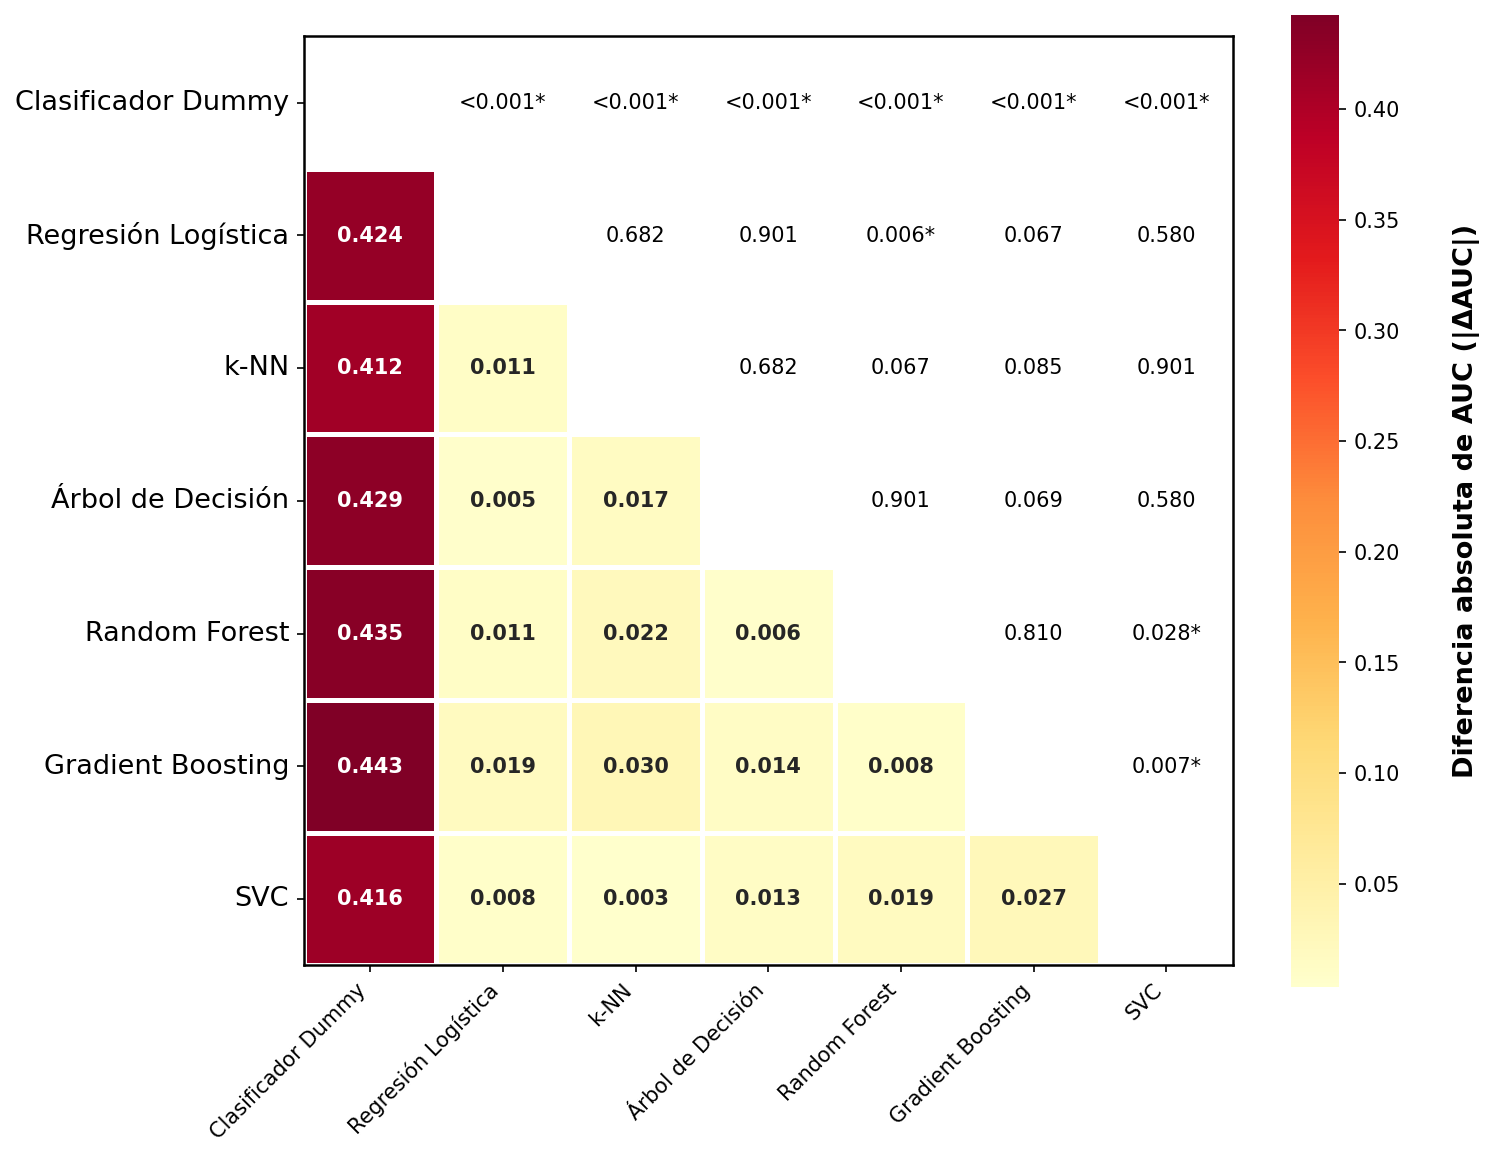

In [22]:
plot_delong_matrix(modelos_a_comparar, X_test, y_test, spanish = True)

Dado que las diferencias de ROC-AUC entre los modelos de alto rendimiento no resultan estadísticamente sustanciales según el *test de DeLong* ($p > 0.05$), la selección final debe fundamentarse en criterios de estabilidad, generalización y utilidad clínica. Bajo este análisis, la balanza se inclina levemente hacia el **Árbol de Decisión** como la solución óptima para el protocolo. Aunque el **Gradient Boosting** presenta una sensibilidad (*Recall*) nominalmente superior ($0.888$ frente a $0.879$), esta mínima ganancia se ve opacada por una marcada inestabilidad diagnóstica, reflejada en una caída de rendimiento de $0.052$ entre las fases de entrenamiento y prueba.

En un entorno médico, la fiabilidad de un modelo es tan crítica como su potencia absoluta; el **Árbol de Decisión** no solo ofrece una sensibilidad más estable con una degradación mínima de apenas $0.029$, sino que su estructura de reglas jerárquicas emula el razonamiento clínico humano, permitiendo una validación inmediata por parte del especialista. Al no existir una superioridad estadística que justifique la adopción de una arquitectura de "*caja negra*" como el ensamble, el principio de parsimonia dicta que el modelo más simple es el más adecuado. El **Árbol de Decisión** garantiza una generalización robusta frente a nuevos pacientes y una transparencia operativa total, transformando una predicción estadística en una herramienta de apoyo a la decisión médica ejecutable, segura y metodológicamente íntegra.